In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt


In [128]:
data = pd.read_csv("tripadvisor_review.csv")

data.head()

,User ID,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
0,User 1,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,User 2,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32
2,User 3,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50
3,User 4,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86
4,User 5,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54


In [129]:
data.columns = [
    'User_ID', 'Art_Galleries', 'Dance_Clubs', 'Juice_Bars', 'Restaurants',
    'Museums', 'Resorts', 'Parks', 'Beaches', 'Theaters', 'Religious_Institutions'
]

# Display first 5 rows to check
data.head()

,User_ID,Art_Galleries,Dance_Clubs,Juice_Bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious_Institutions
0,User 1,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,User 2,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32
2,User 3,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50
3,User 4,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86
4,User 5,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54


In [130]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 980 non-null    object 
 1   Art_Galleries           980 non-null    float64
 2   Dance_Clubs             980 non-null    float64
 3   Juice_Bars              980 non-null    float64
 4   Restaurants             980 non-null    float64
 5   Museums                 980 non-null    float64
 6   Resorts                 980 non-null    float64
 7   Parks                   980 non-null    float64
 8   Beaches                 980 non-null    float64
 9   Theaters                980 non-null    float64
 10  Religious_Institutions  980 non-null    float64
dtypes: float64(10), object(1)
memory usage: 84.3+ KB


In [131]:
data.isnull().sum()

User_ID                   0
Art_Galleries             0
Dance_Clubs               0
Juice_Bars                0
Restaurants               0
Museums                   0
Resorts                   0
Parks                     0
Beaches                   0
Theaters                  0
Religious_Institutions    0
dtype: int64

In [132]:
data_clean = data.drop(columns=['User_ID'])
data_clean.head()


,Art_Galleries,Dance_Clubs,Juice_Bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious_Institutions
0,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32
2,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50
3,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86
4,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54


In [133]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data_clean)

scaled_df = pd.DataFrame(scaled_data, columns=data_clean.columns)
scaled_df.head()


,Art_Galleries,Dance_Clubs,Juice_Bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious_Institutions
0,0.204861,0.494505,0.618911,0.142857,0.228395,0.629834,0.6,0.381443,0.444444,0.184211
1,0.236111,0.604396,0.724928,0.148936,0.419753,0.839779,1.0,0.216495,0.460905,0.118421
2,0.305556,0.219780,0.117479,0.115502,0.055556,0.386740,0.4,0.391753,0.234568,0.236842
3,0.038194,0.494505,0.045845,0.127660,0.123457,0.381215,0.4,0.556701,0.341564,0.473684
4,0.059028,0.329670,0.300860,0.127660,0.456790,0.519337,0.4,0.371134,0.181070,0.263158


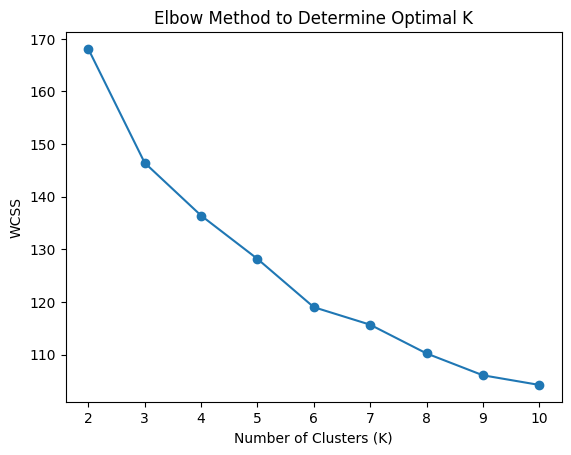

In [134]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method to Determine Optimal K")
plt.show()


In [135]:
kmeans_temp = KMeans(n_clusters=6, random_state=42)
temp_labels = kmeans_temp.fit_predict(scaled_data)

silhouette_avg = silhouette_score(scaled_data, temp_labels)
silhouette_avg

0.1618113212405641

In [136]:
kmeans = KMeans(n_clusters=6, random_state=42)

cluster_labels = kmeans.fit_predict(scaled_data)

data_clean['Cluster'] = cluster_labels

data_clean.head()

,Art_Galleries,Dance_Clubs,Juice_Bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious_Institutions,Cluster
0,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42,1
1,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32,1
2,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50,3
3,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86,3
4,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54,4


In [137]:
data_clean['Cluster'].value_counts()

Cluster
3    217
2    187
1    176
4    147
0    137
5    116
Name: count, dtype: int64

In [138]:
kmeans_means = data_clean.groupby('Cluster').mean()
kmeans_means



,Art_Galleries,Dance_Clubs,Juice_Bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious_Institutions
Cluster,,,,,,,,,,
0,0.862044,1.208467,0.579197,0.510803,0.970365,1.953723,3.179781,2.996642,1.992117,2.844161
1,0.872330,1.459773,2.259773,0.595568,1.131250,2.170341,3.193239,2.791477,1.585057,2.462500
2,0.933797,1.332193,0.418021,0.386845,0.755508,1.434011,3.170963,2.838770,1.463957,3.256043
3,0.839908,1.329217,0.390968,0.593687,0.673088,1.582120,3.179631,2.812396,1.542304,2.714700
4,0.970272,1.527075,1.174150,0.649796,1.356599,2.421633,3.182313,2.806190,1.519456,2.564898
5,0.898190,1.215862,1.554828,0.434138,0.880517,1.628793,3.180431,2.783362,1.330690,2.975690


In [139]:
kmeans_labels = {
    0: "Nature & Beach-Oriented Tourists",
    1: "Entertainment & Leisure Seekers",
    2: "Religious & Cultural Tourists",
    3: "Balanced Sightseeing Tourists",
    4: "High-Engagement Multi-Interest Tourists",
    5: "Relaxed Leisure Tourists"
}

data_clean['Cluster_Label'] = data_clean['Cluster'].map(kmeans_labels)



In [140]:
data_clean[['Cluster', 'Cluster_Label']].head(10)


,Cluster,Cluster_Label
0,1,Entertainment & Leisure Seekers
1,1,Entertainment & Leisure Seekers
2,3,Balanced Sightseeing Tourists
3,3,Balanced Sightseeing Tourists
4,4,High-Engagement Multi-Interest Tourists
5,2,Religious & Cultural Tourists
6,2,Religious & Cultural Tourists
7,3,Balanced Sightseeing Tourists
8,4,High-Engagement Multi-Interest Tourists
9,2,Religious & Cultural Tourists


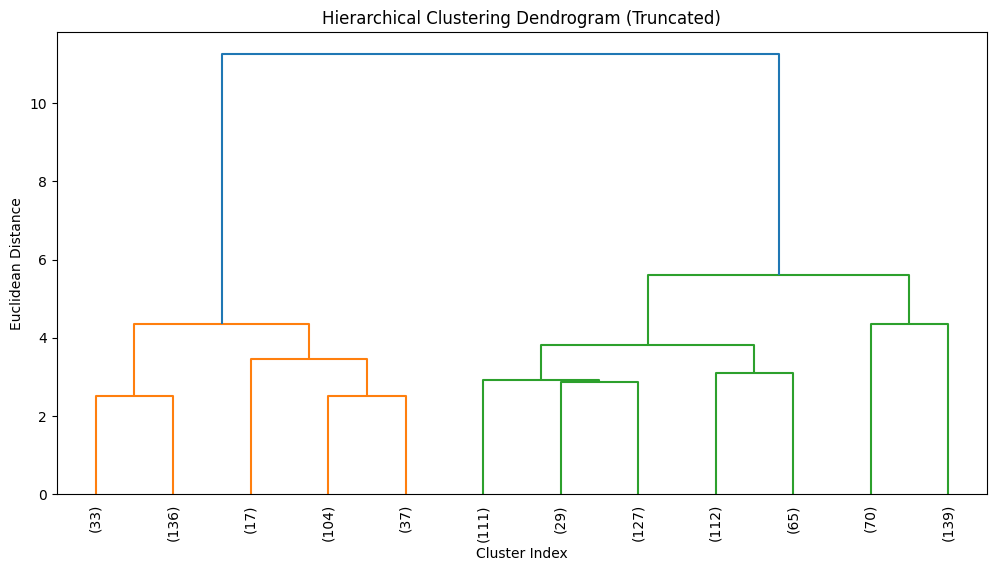

In [141]:
linked = linkage(scaled_data, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=12, leaf_rotation=90., leaf_font_size=10.)
plt.xlabel("Cluster Index")
plt.ylabel("Euclidean Distance")
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.show()




In [142]:
hierarchical_labels = fcluster(linked, 6, criterion='maxclust')
hierarchical_df = data_clean.copy()
hierarchical_df = hierarchical_df.drop(columns=['Cluster', 'Cluster_Label'], errors='ignore')

hierarchical_df['Hierarchical_Cluster'] = hierarchical_labels
hierarchical_df.head()

,Art_Galleries,Dance_Clubs,Juice_Bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious_Institutions,Hierarchical_Cluster
0,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42,1
1,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32,1
2,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50,4
3,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86,4
4,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54,2


In [153]:
hier_silhouette_avg = silhouette_score(scaled_data, hierarchical_labels)
hier_silhouette_avg


0.11755988663962905

In [144]:
hierarchical_means = hierarchical_df.groupby('Hierarchical_Cluster').mean()
hierarchical_means

,Art_Galleries,Dance_Clubs,Juice_Bars,Restaurants,Museums,Resorts,Parks,Beaches,Theaters,Religious_Institutions
Hierarchical_Cluster,,,,,,,,,,
1,0.843373,1.484734,2.248876,0.569882,1.150178,2.151124,3.192485,2.768698,1.534438,2.470178
2,0.909241,1.466329,1.340696,0.734114,1.265823,2.301709,3.183797,2.851646,1.576772,2.568861
3,0.825618,1.407041,0.583633,0.492210,0.915581,1.837191,3.179139,2.905318,1.855243,2.882060
4,0.972938,1.175141,0.463107,0.544011,0.658644,1.577966,3.179322,2.796836,1.457740,2.733616
5,0.904286,1.218857,1.576571,0.419571,0.787429,1.545714,3.180286,2.750286,1.209000,3.036571
6,0.958201,1.251511,0.381223,0.377482,0.794245,1.444604,3.169496,2.853309,1.378417,3.266043


In [145]:
hierarchical_label_map = {
    1: "Relaxation & Culture-Oriented Tourists",
    2: "Social & Nightlife Seekers",
    3: "Spiritual & Nature-Focused Tourists",
    4: "Well-Rounded Experience Seekers",
    5: "Pilgrimage & Nature Travelers",
    6: "Casual Leisure & Dining Tourists"
}

hierarchical_df['Hierarchical_Label'] = hierarchical_df['Hierarchical_Cluster'].map(hierarchical_label_map)


In [146]:
hierarchical_df[['Hierarchical_Cluster', 'Hierarchical_Label']].head(10)


,Hierarchical_Cluster,Hierarchical_Label
0,1,Relaxation & Culture-Oriented Tourists
1,1,Relaxation & Culture-Oriented Tourists
2,4,Well-Rounded Experience Seekers
3,4,Well-Rounded Experience Seekers
4,2,Social & Nightlife Seekers
5,6,Casual Leisure & Dining Tourists
6,6,Casual Leisure & Dining Tourists
7,6,Casual Leisure & Dining Tourists
8,2,Social & Nightlife Seekers
9,3,Spiritual & Nature-Focused Tourists


In [147]:
comparison_table = pd.crosstab(
    data_clean['Cluster'], 
    hierarchical_df['Hierarchical_Cluster']
)
comparison_table


Hierarchical_Cluster,1,2,3,4,5,6
Cluster,,,,,,
0,0,9,121,5,0,2
1,152,23,0,1,0,0
2,0,0,35,13,4,135
3,0,12,63,140,0,2
4,13,99,25,9,1,0
5,4,15,23,9,65,0


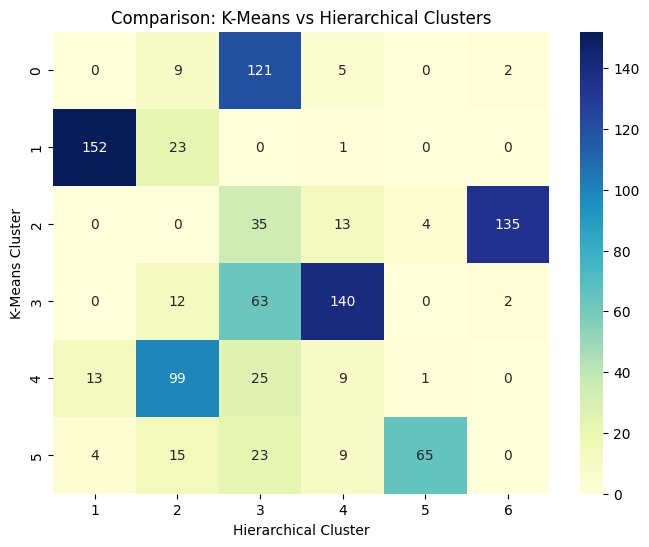

In [148]:
plt.figure(figsize=(8,6))
sns.heatmap(comparison_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Comparison: K-Means vs Hierarchical Clusters")
plt.xlabel("Hierarchical Cluster")
plt.ylabel("K-Means Cluster")
plt.show()


In [149]:
silhouette_comparison = pd.DataFrame({
    "Clustering Method": ["K-Means", "Hierarchical"],
    "Silhouette Score": [silhouette_avg, hier_silhouette_avg]
})

silhouette_comparison

,Clustering Method,Silhouette Score
0,K-Means,0.161811
1,Hierarchical,0.117560


In [154]:
 hierarchical_df['Hierarchical_Cluster'].value_counts()


Hierarchical_Cluster
3    267
4    177
1    169
2    158
6    139
5     70
Name: count, dtype: int64

In [155]:
cluster_size_df = pd.DataFrame({
    "K-Means Cluster Size": data_clean['Cluster'].value_counts().sort_index(),
    "Hierarchical Cluster Size": hierarchical_df['Hierarchical_Cluster'].value_counts().sort_index()
})

cluster_size_df


,K-Means Cluster Size,Hierarchical Cluster Size
0,137.0,NaN
1,176.0,169.0
2,187.0,158.0
3,217.0,267.0
4,147.0,177.0
5,116.0,70.0
6,NaN,139.0
